In [30]:
import pandas as pd

df = pd.read_csv("C:\\Users\\rizwa\Desktop\\Diabetes Prediction System\\dataset\\diabetes.csv")

print(df.head())
print(df.shape)

# Imports the Pandas library and assigns it the alias 'pd'. Pandas is used for data manipulation and analysis.

# df = pd.read_csv("D:\\PYTHON\\diabetes.csv")
# Loads the diabetes dataset from a CSV file and stores it in a DataFrame named 'df'.

# print(df.head())
# Displays the first five rows of the dataset to provide an initial overview of the data.

# print(df.shape)
# Returns the dimensions of the dataset, showing the total number of rows and columns.


   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  
(768, 9)


In [31]:
df.info()

# df.info()
# Displays a concise summary of the DataFrame, including column names,
# data types, number of non-null values, and memory usage.
# It is used to understand the dataset structure and identify missing values.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [32]:
df.isnull().sum()


# Checks for missing (null) values in each column of the dataset.
# The isnull() function identifies missing values, and sum() counts
# the total number of missing values present in each column.

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

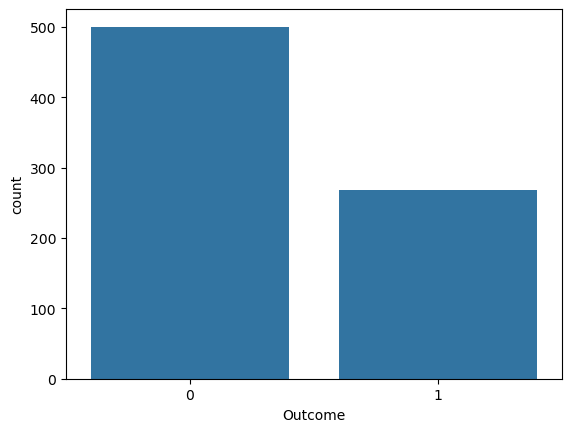

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Outcome', data=df)
plt.show()

# import seaborn as sns
# Imports the Seaborn library, which is used for statistical data visualization.

# import matplotlib.pyplot as plt
# Imports Matplotlib's pyplot module, used for creating and displaying plots.

# sns.countplot(x='Outcome', data=df)
# Creates a countplot that shows the frequency of each category in the 'Outcome' column.
# It visualizes how many samples belong to each class (0 = Non-Diabetic, 1 = Diabetic).

# plt.show()
# Displays the generated plot on the screen.

# 500-> Diabetic
#268-> Non Diabetic

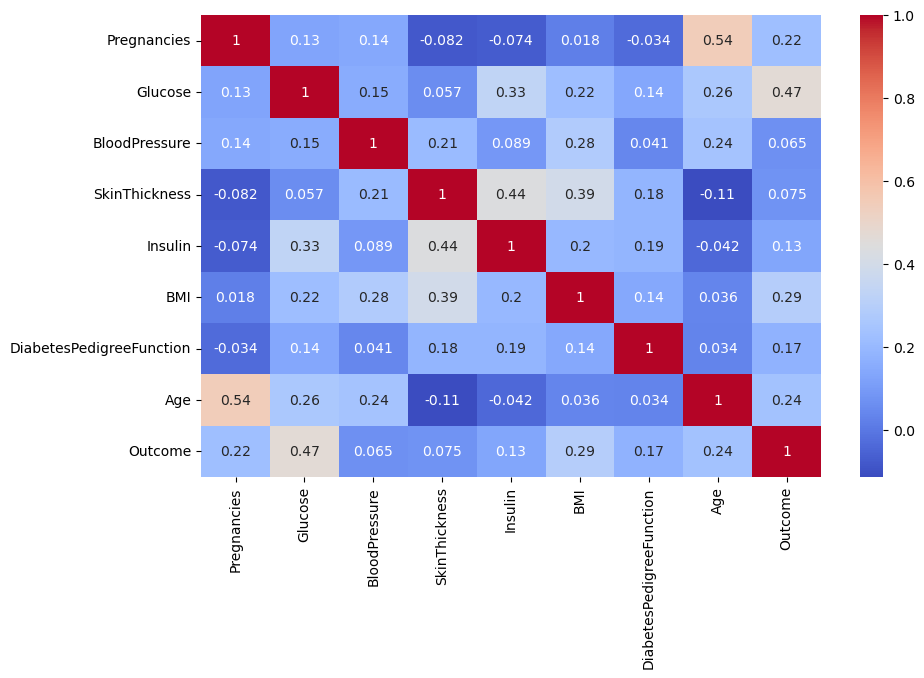

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.show()

# Creates a correlation heatmap to show relationships between all features.
# Values close to +1 mean strong positive correlation.
# Values close to -1 mean strong negative correlation.
# Helps identify which features affect diabetes outcome the most.

In [35]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

# X = df.drop("Outcome", axis=1)
# Removes the "Outcome" column from the dataset and stores the remaining columns in X.
# X represents the input features (independent variables) used for model training.

# y = df["Outcome"]
# Extracts the "Outcome" column and stores it in y.
# y represents the target variable (dependent variable) that we want to predict.

In [36]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# from sklearn.model_selection import train_test_split
# Imports the train_test_split function from Scikit-learn, used to split dataset into training and testing sets.

# X_train, X_test, y_train, y_test = train_test_split(...)
# Splits the dataset into training and testing parts:
# X_train → input features for training the model
# X_test → input features for testing the model
# y_train → target values for training
# y_test → target values for testing

# test_size=0.2
# 20% of the data is used for testing, while 80% is used for training the model.

# random_state=42
# Ensures reproducibility of the split so that the same results are obtained every time the code is run.

In [37]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# from sklearn.preprocessing import StandardScaler
# Imports StandardScaler from Scikit-learn, which is used for feature scaling.

# scaler = StandardScaler()
# Creates an instance of StandardScaler.

# X_train = scaler.fit_transform(X_train)
# Fits the scaler on training data and transforms it.
# It calculates mean and standard deviation, then scales the training features.

# X_test = scaler.transform(X_test)
# Uses the same scaling parameters (mean & std from training data)
# to transform the test data, ensuring consistency.

In [38]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train, y_train)


# from sklearn.linear_model import LogisticRegression
# Imports the Logistic Regression algorithm from Scikit-learn for classification tasks.

# model = LogisticRegression()
# Creates an instance of the Logistic Regression model.

# model.fit(X_train, y_train)
# Trains the model using the training data (X_train and y_train).
# The model learns the relationship between input features and the target variable.

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [39]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier()
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

# Random Forest is an ensemble learning algorithm that combines multiple decision trees.
# It improves accuracy and reduces overfitting by averaging multiple tree predictions.

In [40]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier()
knn_model.fit(X_train, y_train)

knn_pred = knn_model.predict(X_test)

# KNN is a distance-based algorithm that classifies a sample based on its nearest neighbors.
# It assumes similar data points exist close to each other in feature space.

In [41]:


from sklearn.metrics import accuracy_score

lr_acc = accuracy_score(y_test, pred)
rf_acc = accuracy_score(y_test, rf_pred)
knn_acc = accuracy_score(y_test, knn_pred)

print("Logistic Regression Accuracy:", lr_acc)
print("Random Forest Accuracy:", rf_acc)
print("KNN Accuracy:", knn_acc)

Logistic Regression Accuracy: 0.7532467532467533
Random Forest Accuracy: 0.7597402597402597
KNN Accuracy: 0.6948051948051948


In [42]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# Logistic Regression Evaluation
lr_cm = confusion_matrix(y_test, pred)
print("Logistic Regression Confusion Matrix:\n", lr_cm)

print("\nClassification Report:\n")
print(classification_report(y_test, pred))


# Random Forest Evaluation
rf_cm = confusion_matrix(y_test, rf_pred)
print("Random Forest Confusion Matrix:\n", rf_cm)

print("\nClassification Report:\n")
print(classification_report(y_test, rf_pred))


# 3. KNN Evaluation
knn_cm = confusion_matrix(y_test, knn_pred)
print("KNN Confusion Matrix:\n", knn_cm)

print("\nClassification Report:\n")
print(classification_report(y_test, knn_pred))


# This code is used to evaluate the performance of different machine learning models using important metrics. 
# The `confusion_matrix` function shows the number of correct and incorrect predictions by comparing actual and predicted values, 
# while the `classification_report` provides detailed results including precision, recall, and F1-score for each class.
# Precision tells how many predicted positive cases are actually correct, 
# recall shows how many actual positive cases were correctly identified, 
# and F1-score gives a balanced measure of both. 
# Overall, this evaluation helps us understand how well each model (Logistic Regression, Random Forest, and KNN) is performing and assists in selecting the best model for the Diabetes Prediction System.




Logistic Regression Confusion Matrix:
 [[79 20]
 [18 37]]

Classification Report:

              precision    recall  f1-score   support

           0       0.81      0.80      0.81        99
           1       0.65      0.67      0.66        55

    accuracy                           0.75       154
   macro avg       0.73      0.74      0.73       154
weighted avg       0.76      0.75      0.75       154

Random Forest Confusion Matrix:
 [[81 18]
 [19 36]]

Classification Report:

              precision    recall  f1-score   support

           0       0.81      0.82      0.81        99
           1       0.67      0.65      0.66        55

    accuracy                           0.76       154
   macro avg       0.74      0.74      0.74       154
weighted avg       0.76      0.76      0.76       154

KNN Confusion Matrix:
 [[79 20]
 [27 28]]

Classification Report:

              precision    recall  f1-score   support

           0       0.75      0.80      0.77        99
          

In [43]:
sample = [[2,120,70,20,85,28.5,0.35,30]]

sample = scaler.transform(sample)

prediction = model.predict(sample)

print(prediction)


# sample = [[2,120,70,20,85,28.5,0.35,30]]
# Defines a single patient's input data in the same order as the training features.

# sample = scaler.transform(sample)
# Applies the same feature scaling used during training to the new input data.

# prediction = model.predict(sample)
# Uses the trained model to predict whether the patient is diabetic or not.

# print(prediction)
# Displays the prediction result:
# 0 → Non-Diabetic
# 1 → Diabetic

[0]


C:\Users\rizwa\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [44]:
import joblib

joblib.dump(model, "diabetes_model.pkl")
joblib.dump(scaler, "scaler.pkl")


# import joblib
# Imports the joblib library, used for saving and loading trained machine learning models.

# joblib.dump(model, "diabetes_model.pkl")
# Saves the trained Logistic Regression model into a file named "diabetes_model.pkl".
# This allows the model to be reused later without retraining.

# joblib.dump(scaler, "scaler.pkl")
# Saves the fitted StandardScaler object into a file named "scaler.pkl".
# This ensures that the same scaling can be applied during future predictions.

['scaler.pkl']